<a href="https://colab.research.google.com/github/rudmaxx/DTA_Python/blob/main/Statistic/practice_stat_tests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Статистичні тести: практикум

**Тривалість:** ~4 години · бібліотека `scipy.stats`

---

Цей практикум закріплює лекцію про p-значення та статистичну значущість. Він влаштований так:

- 🟦 **Теорія** — короткий блок перед кожним тестом: *коли* його обирати, *чому*, *як читати результат*.
- ✏️ **Завдання (код)** — ви пишете код, що проводить тест.
- 💬 **Інтерпретація** — ви **своїми словами** пояснюєте, що означає результат. Це найважливіша частина! Аналітик, який уміє порахувати p-значення, але не вміє його пояснити — це лише калькулятор.

## Як працювати
1. Читайте теоретичний блок.
2. Виконуйте завдання на код (Shift+Enter).
3. На кожне питання інтерпретації відповідайте **повним реченням людською мовою** — так, ніби пояснюєте керівнику без технічної освіти.

## Загальне правило
- `p < 0.05` → статистично значущо → відхиляємо H₀
- `p ≥ 0.05` → не значущо → не відхиляємо H₀

> 💡 Тримайте поруч шпаргалку вибору тесту з лекції. Половина завдань — про те, щоб **обрати правильний тест**.

---

## Підготовка

Запустіть цю клітинку. Ми працюємо з двома наборами даних:
- **`shop_customers.csv`** — 500 клієнтів інтернет-магазину
- **`ab_test.csv`** — результати A/B-тесту (8000 сесій)


In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv("shop_customers.csv")
ab = pd.read_csv("ab_test.csv")

print("Клієнти:", df.shape)
print("A/B тест:", ab.shape)
df.head()

Клієнти: (500, 11)
A/B тест: (8000, 3)


,customer_id,gender,age,country,channel,device,spend,session_min,sat_before,sat_after,purchased
0,1001,Ч,23,Німеччина,Реклама,Desktop,997.11,22.2,6,7,Так
1,1002,Ч,38,Україна,Органіка,Desktop,510.09,19.8,5,8,Ні
2,1003,Ч,20,Україна,Соцмережі,Desktop,789.71,21.0,7,8,Ні
3,1004,Ч,40,Німеччина,Соцмережі,Desktop,1041.02,17.4,8,9,Ні
4,1005,Ч,18,Україна,Реклама,Desktop,944.34,23.5,6,7,Ні


### Опис даних `shop_customers.csv`

| Стовпець | Опис | Тип |
|---|---|---|
| `customer_id` | ID клієнта | — |
| `gender` | Стать (Ч/Ж) | категоріальний |
| `age` | Вік | числовий |
| `country` | Країна | категоріальний |
| `channel` | Канал залучення (Органіка/Реклама/Соцмережі) | категоріальний |
| `device` | Пристрій (Mobile/Desktop) | категоріальний |
| `spend` | Витрати клієнта, грн | числовий |
| `session_min` | Час на сайті, хв | числовий |
| `sat_before` | Задоволеність ДО редизайну (1-10) | числовий |
| `sat_after` | Задоволеність ПІСЛЯ редизайну (1-10) | числовий |
| `purchased` | Чи зробив покупку (Так/Ні) | категоріальний |

Спочатку завжди корисно роздивитись дані.

#### ✏️ Завдання 1 (код)

Виведіть основну статистику по числових стовпцях (підказка: метод `.describe()`).

In [3]:
# Завдання 1:
df.describe()

,customer_id,age,spend,session_min,sat_before,sat_after
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,1250.500000,34.646000,845.016340,20.739400,6.536000,7.138000
std,144.481833,10.961615,333.460589,10.532489,1.523597,1.826919
min,1001.000000,18.000000,50.000000,1.000000,2.000000,1.000000
25%,1125.750000,26.000000,612.627500,13.100000,6.000000,6.000000
50%,1250.500000,34.000000,834.750000,20.850000,7.000000,7.000000
75%,1375.250000,41.250000,1070.395000,27.400000,8.000000,9.000000
max,1500.000000,69.000000,1952.020000,52.200000,10.000000,10.000000


#### ✏️ Завдання 2 (код)

Скільки клієнтів у кожному каналі залучення? (підказка: `.value_counts()` на стовпці `channel`)

In [4]:
# Завдання 2:
df['channel'].value_counts()

,count
channel,
Органіка,174
Соцмережі,167
Реклама,159


---
# Розділ 1. Одновибірковий t-тест

## 🟦 Теорія: коли і чому

**Коли обирати:** коли у вас є **одна** група числових даних, і ви хочете порівняти її **середнє** з якимось **фіксованим, наперед відомим числом** (ціль, норматив, заявлене значення).

**Чому саме він:** ми перевіряємо, чи відхилення нашого середнього від цільового числа реальне, чи це випадковість вибірки.

**Гіпотези:**
- H₀: середнє = цільове число
- H₁: середнє ≠ цільове число

**Функція:** `stats.ttest_1samp(дані, цільове_число)`

**Як читати:** дивимось на p-значення. Якщо `p < 0.05` — середнє значущо відрізняється від цільового.

**Приклад із життя:** виробник заявляє, що пакет чипсів важить 100 г. Ви зважили 50 пакетів. Чи справді середня вага = 100 г, чи вас обманюють?

**Сценарій:** маркетолог стверджує, що середній час на сайті становить 20 хвилин. Перевіримо це.

#### ✏️ Завдання 3 (код)

Порахуйте фактичний середній `session_min`. Потім проведіть одновибірковий t-тест, щоб перевірити, чи відрізняється він від 20. Виведіть t-статистику та p-значення.

In [62]:
# Завдання 3:
mean_session_min = df["session_min"].mean()
print(f"Фактичне середнє: {mean_session_min:.1f} хв")

t_stat, p_value = stats.ttest_1samp(df["session_min"], 20)

print(f"p-значення:   {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ p < 0.05 → значущо: середнє ВІДРІЗНЯЄТЬСЯ від 20")
else:
    print("\n❌ p ≥ 0.05 → не значущо: немає підстав казати, що середнє ≠ 20")


Фактичне середнє: 20.7 хв
p-значення:   0.1171

❌ p ≥ 0.05 → не значущо: немає підстав казати, що середнє ≠ 20


#### 💬 Інтерпретація 1

Чи відрізняється середній час на сайті від заявлених 20 хвилин? Сформулюйте висновок для маркетолога: він мав рацію чи ні? Чому ви так вважаєте (спирайтесь на p-значення)?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Фактичний середній час перебування на сайті становить 20.7 хвилини, що трохи більше за заявлені 20 хвилин. Тому твердження маркетолога можна вважати обґрунтованим.*

**Другий сценарій:** керівник вважає, що середні витрати клієнта = 850 грн.

#### ✏️ Завдання 4 (код)

Перевірте за допомогою одновибіркового t-тесту, чи середні витрати (`spend`) відрізняються від 850 грн.

In [6]:
# Завдання 4:
mean_spend = df["spend"].mean()
print(f"Середні витрати: {mean_spend:.1f} грн")

t_stat, p_value = stats.ttest_1samp(df["spend"], 850)
print(f"t-статистика: {t_stat:.3f}")
print(f"p-значення:   {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ p < 0.05 → значущо:  ВІДРІЗНЯЄТЬСЯ від 850")
else:
    print("\n❌ p ≥ 0.05 → не значущої різниці від 850 не виявлено")

Середні витрати: 845.0 грн
t-статистика: -0.334
p-значення:   0.7384

❌ p ≥ 0.05 → не значущої різниці від 850 не виявлено


#### 💬 Інтерпретація 2

Що показав тест? Чи можна сказати, що середні витрати дорівнюють 850 грн? Поясніть, чому тут ми НЕ відхиляємо нульову гіпотезу (зверніть увагу на формулювання: чи це означає, що середнє точно дорівнює 850?).

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Оскільки p = 0.7384 > 0.05, статистично значущої різниці між фактичними середніми витратами (845 грн) та 850 грн не виявлено. Нульову гіпотезу не відхиляємо, але це не доводить, що середні витрати точно дорівнюють 850 грн.*

---
# Розділ 2. Двовибірковий t-тест (незалежні групи)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви порівнюєте **середні двох РІЗНИХ, незалежних груп** числових даних.

**Чому саме він:** хочемо дізнатись, чи різниця між групами реальна, чи могла виникнути випадково.

**Ключова умова — групи НЕЗАЛЕЖНІ:** різні люди в кожній групі (на відміну від парного тесту, де ті самі люди двічі).

**Гіпотези:**
- H₀: середнє групи 1 = середнє групи 2
- H₁: вони відрізняються

**Функція:** `stats.ttest_ind(група1, група2)`

**Приклад із життя:** чи відрізняється середня зарплата у двох відділах? Чи витрачають більше клієнти з міста А порівняно з містом Б?

**Сценарій:** чи витрачають клієнти з мобільних більше, ніж з десктопу?

#### ✏️ Завдання 5 (код)

Розділіть `spend` на дві групи за `device` (Mobile та Desktop). Виведіть середнє кожної групи і проведіть двовибірковий t-тест.

In [7]:
# Завдання 5:
spend_mobile = df[df["device"] == "Mobile"]["spend"]
spend_desktop = df[df["device"] == "Desktop"]["spend"]

print(f"Mobile : {spend_mobile.mean():.1f} грн")
print(f"Desktop : {spend_desktop.mean():.1f} грн")

t_stat , p_value = stats.ttest_ind(spend_mobile, spend_desktop)
print(f"\np-значення :{p_value:.4f}")

if p_value < 0.05:
  print("Значуща різниця між пристроями")
else:
 print("Значущої різниці не виявлено")

Mobile : 835.2 грн
Desktop : 861.2 грн

p-значення :0.3993
Значущої різниці не виявлено


#### 💬 Інтерпретація 3

Чи є значуща різниця у витратах між Mobile та Desktop? Якби ви були аналітиком, чи порадили б компанії інвестувати в мобільну версію на основі цього результату?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*p > 0.05  Статистично значущої різниці не виявлено. На основі лише цих даних робити висновок про необхідність інвестицій не можна. Як аналітик, я б не рекомендував інвестувати в мобільну версію лише на основі цього результату, оскільки дані не показують, що один тип пристрою приносить більше доходу за інший.*


**Сценарій:** чи різниться час на сайті залежно від статі?

#### ✏️ Завдання 6 (код)

Порівняйте `session_min` між чоловіками та жінками за допомогою двовибіркового t-тесту.

In [30]:
# Завдання 6:
m = df[df['gender'] == 'Ч']['session_min']
w = df[df['gender'] == 'Ж']['session_min']

print(f"Чоловіки : {m.mean():.1f} хв")
print(f"Жінки : {w.mean():.1f} хв")

t_stat, p_value = stats.ttest_ind(m, w)
print(f"\np-значення :{p_value:.4f}")

if p_value < 0.05:
  print("Значущо")
else:
 print("Значущої різниці не виявлено")

Чоловіки : 20.8 хв
Жінки : 20.6 хв

p-значення :0.8163
Значущої різниці не виявлено


#### 💬 Інтерпретація 4

Сформулюйте висновок. Якщо різниця не значуща — що це означає на практиці для команди маркетингу?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Це означає, що наявні дані не дають підстав вважати, що стать користувача впливає на тривалість сесії. Тому немає сенсу розробляти окремі маркетингові стратегії або персоналізувати кампанії лише за ознакою статі, якщо метою є збільшення часу перебування користувачів у застосунку. Доцільніше шукати інші фактори (наприклад, тип пристрою, джерело трафіку, вік користувачів чи їхню активність), які можуть сильніше впливати на цей показник.
*

---
# Розділ 3. Парний t-тест

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви маєте **два виміри в ОДНИХ І ТИХ САМИХ обʼєктів** — типово «до і після» якоїсь зміни.

**Чому саме він (а не звичайний t-тест):** виміри пов'язані (той самий клієнт до і після). Парний тест враховує цей зв'язок і тому **потужніший** — він краще виявляє реальні зміни.

**Гіпотези:**
- H₀: середня різниця (після − до) = 0 (зміни немає)
- H₁: середня різниця ≠ 0 (зміна є)

**Функція:** `stats.ttest_rel(до, після)`

**Приклад із життя:** вага пацієнтів до і після дієти. Продуктивність працівників до і після тренінгу. Бали студентів до і після курсу.

> ⚠️ Головна підказка для вибору: якщо ви бачите слова «до/після», «був/став», «той самий обʼєкт двічі» — це парний тест.

**Сценарій:** компанія зробила редизайн сайту і виміряла задоволеність тих самих клієнтів до (`sat_before`) і після (`sat_after`).

#### ✏️ Завдання 7 (код)

Проведіть парний t-тест, щоб перевірити, чи змінилася задоволеність клієнтів після редизайну. Виведіть середні значення до і після, а також p-значення.

In [34]:
# Завдання 7:
print(f" Задоволеність ДО: {df['sat_before'].mean():.2f} ")
print(f" Задоволеність Після: {df['sat_after'].mean():.2f} ")

t_stat, p_value = stats.ttest_rel(df['sat_before'], df['sat_after'])
print(f"\np-значення :{p_value:.2e}")

if p_value < 0.05:
  print("Задоволеність значущо змінилася")
else:
 print("Значущої зміни не виявлено")


 Задоволеність ДО: 6.54 
 Задоволеність Після: 7.14 

p-значення :1.57e-26
Задоволеність значущо змінилася


#### 💬 Інтерпретація 5

Чи спрацював редизайн? Поясніть, чому тут доречний саме ПАРНИЙ тест, а не звичайний двовибірковий. Що було б не так, якби ми використали `ttest_ind`?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Задоволеність зросла з 6,54 до 7,14, р=1,57е-26.  Відхиляємо H₀. Редизайн спрацював і задоволеність зросла. Потрібно використовувати саме такий тест тому що вимірюємо одних і тих самих клієнтів двічі. Цей тест показує різницю для кожного клієнта окремо. ttest_ind не підходив тому що він використовується для незалежних груп,тоді як цей випадок має зв'язок *

---
# Розділ 4. ANOVA (дисперсійний аналіз)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви порівнюєте середні **ТРЬОХ або більше груп** числових даних.

**Чому не кілька t-тестів:** якби ми порівнювали групи попарно багатьма t-тестами, ми б накопичили помилки I роду (згадайте проблему множинних порівнянь!). ANOVA перевіряє все одним тестом.

**Гіпотези:**
- H₀: середні ВСІХ груп однакові
- H₁: принаймні одна група відрізняється

**Функція:** `stats.f_oneway(група1, група2, група3, ...)`

**Важливе обмеження:** ANOVA каже, що різниця Є, але не каже, **між якими саме** групами. Для цього потрібні додаткові (post-hoc) тести.

**Приклад із життя:** чи відрізняється врожайність при трьох різних добривах? Чи різний середній дохід у чотирьох регіонах?

**Сценарій:** чи залежать витрати клієнта від каналу залучення (Органіка / Реклама / Соцмережі)?

#### ✏️ Завдання 8 (код)

Виведіть середні `spend` для кожного каналу. Потім проведіть ANOVA, щоб перевірити, чи є значуща різниця між каналами. (Підказка: створіть список груп через цикл або вручну, потім передайте їх у `f_oneway`.)

In [40]:
# Завдання 8:
for ch in df["channel"].unique():
  print(f"{ch}: {df[df['channel'] == ch]['spend'].mean():.1f} грн")

groups = [df[df["channel"] == ch]["spend"] for ch in df["channel"].unique()]
f_stat, p_value = stats.f_oneway(groups[0], groups[1], groups[2])


print(f"p-значення: {p_value:.2e}")

if p_value < 0.05:
  print("Принаймні один канал відрізняється")
else:
 print("Значущої різниці не виявлено")


Реклама: 1057.9 грн
Органіка: 791.3 грн
Соцмережі: 698.4 грн
p-значення: 2.68e-25
Принаймні один канал відрізняється


#### 💬 Інтерпретація 6


Чи відрізняються канали за витратами? Який канал виглядає найприбутковішим? Чому на основі лише ANOVA ми НЕ можемо точно сказати, що, наприклад, Реклама значущо краща за Органіку?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Середні: Реклама - 1058 грн, Органіка - 791 грн, Соцмережі - 698 грн. Результат ANOVA показав p = 2.68е-25, що значно менше 0,05. Отже, між каналами є статистично значущі відмінності за середніми витратами.   
ANOVA відповідає лише на питання:
«Чи є хоча б одна відмінність між середніми значеннями груп?»
Вона не показує, між якими саме каналами ця різниця існує. Для цього потрібно виконати пост-хок аналіз , який порівнює кожну пару каналів окремо і показує, між якими саме є статистично значущі відмінності.  
*

**Сценарій:** чи залежить час на сайті (`session_min`) від країни клієнта?

#### ✏️ Завдання 9 (код)

Проведіть ANOVA для `session_min` за трьома країнами (`country`).

In [43]:
# Завдання 9:
for c in df["country"].unique():
  print(f"{c}: {df[df['country'] == c]['session_min'].mean():.1f} хв")

groups = [df[df["country"] == c]["session_min"] for ch in df["country"].unique()]
f_stat, p_value = stats.f_oneway(groups[0], groups[1], groups[2])

print(f"p-значення: {p_value:.2f}")

if p_value < 0.05:
  print("Принаймні одна країна відрізняється")
else:
 print("Значущої різниці не виявлено")

Німеччина: 21.3 хв
Україна: 20.3 хв
Польща: 21.2 хв
p-значення: 1.00
Значущої різниці не виявлено


#### 💬 Інтерпретація 7

Що показав результат? Сформулюйте висновок про звʼязок країни і часу на сайті.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Результат ANOVA показав, що статистично значущого зв’язку між країною клієнта і часом на сайті не виявлено. Оскільки p-значення = 1,00, а це більше ніж 0,05, ми не відхиляємо нульову гіпотезу.   
За наявними даними країна клієнта не має значущого впливу на тривалість перебування на сайті. Різниця між середніми значеннями для Німеччини, України та Польщі є незначною і може пояснюватися випадковими коливаннями, а не реальною відмінністю між країнами.*

---
# Розділ 5. Хі-квадрат (χ²)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли обидві змінні **категоріальні**, і ви хочете перевірити, чи є між ними **звʼязок**.

**Чому саме він:** t-тест і ANOVA працюють із числами (середніми). Коли даних немає що усереднювати (категорії на кшталт «купив/не купив», «місто», «колір»), використовують хі-квадрат на основі **частот**.

**Гіпотези:**
- H₀: змінні незалежні (звʼязку немає)
- H₁: змінні повʼязані

**Як проводити (два кроки):**
1. Побудувати таблицю спряженості: `pd.crosstab(змінна1, змінна2)`
2. Передати її у `stats.chi2_contingency(таблиця)` — повертає chi2, p, dof, expected

**Приклад із життя:** чи повʼязана стать із вибором категорії товару? Чи залежить рішення про покупку від кольору кнопки (це і є A/B-тест для конверсій!)?

**Сценарій:** чи повʼязаний канал залучення (`channel`) із фактом покупки (`purchased`)?

#### ✏️ Завдання 10 (код)

Побудуйте таблицю спряженості між `channel` та `purchased`, виведіть її, потім проведіть тест хі-квадрат.

In [50]:
# Завдання 10:
contingency = pd.crosstab(df["channel"], df["purchased"])
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"p-значення: {p_value:.2f}")

if p_value < 0.05:
  print("Канал пов'язаний з покупкою")
else:
 print("Зв'язку не виявлено")


purchased   Ні  Так
channel            
Органіка   116   58
Реклама    110   49
Соцмережі  107   60
p-значення: 0.62
Зв'язку не виявлено


#### 💬 Інтерпретація 8

Чи виявив тест звʼязок між каналом залучення та покупкою? Сформулюйте висновок. Якщо звʼязку не виявлено — що це означає для бізнесу (чи варто обирати канал, орієнтуючись на ймовірність покупки)? Якщо звʼязок є — подивіться на частки в таблиці спряженості й опишіть, який канал вигідніший.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*р= 0,62   
Не відхиляємо H₀. Зв'язку між каналом залучення і фактом покупки не виявлено. Канал залучення не впливає на ймовірність покупки - обирати канал варто за іншими критеріями (вартість залучення , обсяг трафіку, середній чек)*

**Сценарій:** чи повʼязана стать (`gender`) із вибором пристрою (`device`)?

#### ✏️ Завдання 11 (код)

Перевірте за допомогою хі-квадрат, чи є звʼязок між статтю та пристроєм.

In [51]:
# Завдання 11:
contingency = pd.crosstab(df["gender"], df["device"])
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"p-значення: {p_value:.2f}")

if p_value < 0.05:
  print("Канал пов'язаний з покупкою")
else:
 print("Зв'язку не виявлено")

device  Desktop  Mobile
gender                 
Ж            93     158
Ч            96     153
p-значення: 0.80
Зв'язку не виявлено


#### 💬 Інтерпретація 9

Сформулюйте висновок. Чи можна за цими даними сказати, що чоловіки й жінки користуються різними пристроями?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*р = 0,8 -Не відхитляємо H₀. Зв'язку між статтю і вибором присторою немає. НЕ можна сказати ,що чоловіки і жінки  користуються різними пристроями - розподіл приблизно однаковий для обох статей.*

---
# Розділ 6. Кореляція

## 🟦 Теорія: коли і чому

**Коли обирати:** коли обидві змінні **числові**, і ви хочете виміряти **силу та напрямок звʼязку** між ними.

**Що повертає:** коефіцієнт кореляції **r** (від −1 до +1) ТА p-значення.
- **r ≈ +1** — сильний прямий звʼязок (одне зростає → інше зростає)
- **r ≈ −1** — сильний зворотний звʼязок (одне зростає → інше спадає)
- **r ≈ 0** — звʼязку немає
- **p-значення** — чи є цей звʼязок статистично значущим

**Функція:** `stats.pearsonr(змінна1, змінна2)`

**Гіпотези:**
- H₀: кореляції немає (r = 0)
- H₁: кореляція є (r ≠ 0)

> ⚠️ **Найважливіше попередження:** кореляція ≠ причинність! Значуща кореляція каже, що звʼязок реальний, але НЕ каже, що одне СПРИЧИНЯЄ інше.

**Приклад із життя:** чи повʼязаний зріст із вагою? Чи більше реклами → більше продажів?

**Сценарій:** чи повʼязаний час на сайті (`session_min`) із витратами (`spend`)?

#### ✏️ Завдання 12 (код)

Порахуйте кореляцію Пірсона між `session_min` та `spend`. Виведіть коефіцієнт r та p-значення. Додатково: побудуйте діаграму розсіювання (scatter plot), щоб побачити звʼязок очима.

Коефіцієнт кореляції r: 0.732
р- значення : 4.05e-85


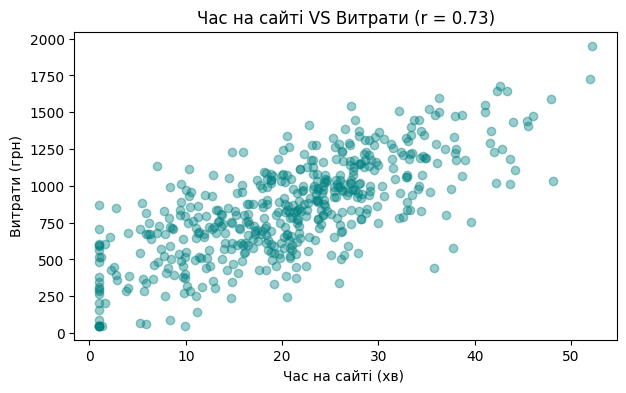

In [53]:
# Завдання 12:
r, p_value = stats.pearsonr(df["session_min"], df["spend"])
print(f"Коефіцієнт кореляції r: {r:.3f}")
print(f"р- значення : {p_value:.2e}")

plt.figure(figsize = (7,4))
plt.scatter(df["session_min"], df["spend"], alpha=0.4 , color='teal')
plt.xlabel("Час на сайті (хв) ")
plt.ylabel("Витрати (грн)")
plt.title(f"Час на сайті VS Витрати (r = {r:.2f})")
plt.show()

#### 💬 Інтерпретація 10

Опишіть звʼязок: він прямий чи зворотний? Сильний чи слабкий? Значущий? І найголовніше: чи можна стверджувати, що довший час на сайті СПРИЧИНЯЄ більші витрати? Поясніть свою думку.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Коефіцієнт кореляції r = 0,732, що свідчить про сильний прямий зв'язок між часом перебування на сайті (session_min) та витратами (spend).

p-значення = 4.05e-85, що значно менше за 0,05, тому цей зв'язок є статистично значущим.

Діаграма розсіювання також показує, що зі збільшенням часу перебування на сайті загалом зростають і витрати користувачів.

Однак не можна стверджувати, що довший час на сайті спричиняє більші витрати. Кореляція показує лише наявність зв'язку між змінними, але не доводить причинно-наслідковий зв'язок. Можливо, користувачі, які планують дорожчі покупки, просто проводять більше часу, обираючи товари, або на обидва показники впливають інші фактори (наприклад, тип товару, намір покупки чи джерело трафіку).*

**Сценарій:** чи повʼязаний вік клієнта (`age`) з його витратами (`spend`)?

#### ✏️ Завдання 13 (код)

Порахуйте кореляцію між `age` та `spend`.

Коефіцієнт кореляції r: -0.042
р- значення : 3.51e-01


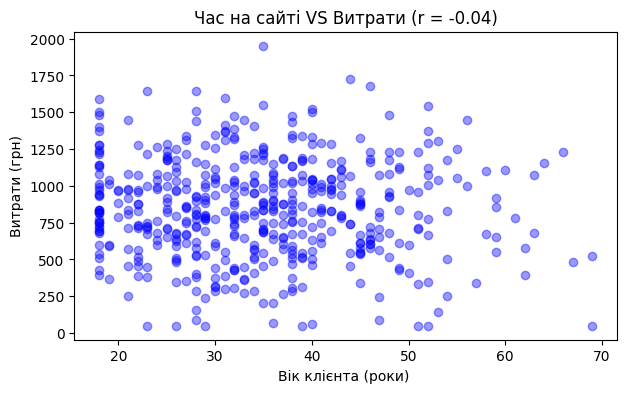

In [55]:
# Завдання 13:
r, p_value = stats.pearsonr(df["age"], df["spend"])
print(f"Коефіцієнт кореляції r: {r:.3f}")
print(f"р- значення : {p_value:.2e}")

plt.figure(figsize = (7,4))
plt.scatter(df["age"], df["spend"], alpha=0.4 , color='blue')
plt.xlabel("Вік клієнта (роки) ")
plt.ylabel("Витрати (грн)")
plt.title(f"Час на сайті VS Витрати (r = {r:.2f})")
plt.show()

#### 💬 Інтерпретація 11

Що показала кореляція? Порівняйте цей результат із попереднім (час на сайті vs витрати). У якому випадку звʼязок сильніший і чому це важливо для бізнесу?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Коефіцієнт кореляції між віком клієнта (age) та витратами (spend) становить r = -0,042, що свідчить про дуже слабкий зворотний зв'язок, який практично відсутній.

p-значення = 0,351, що більше за 0,05, тому статистично значущого зв'язку між віком і витратами не виявлено.

Порівняння з попереднім результатом

Для часу на сайті та витрат було отримано:

r = 0,732 — сильний прямий зв'язок;
p < 0,05 — зв'язок статистично значущий.

Для віку та витрат:

r = -0,042 — зв'язок майже відсутній;
p = 0,351 — зв'язок статистично незначущий.
Чому це важливо для бізнесу?

Отримані результати показують, що час перебування користувача на сайті значно сильніше пов'язаний із сумою витрат, ніж його вік. Це означає, що бізнесу доцільніше аналізувати та покращувати фактори, які збільшують залученість користувачів і час перебування на сайті (зручність навігації, рекомендації товарів, якісний контент), ніж будувати маркетингові стратегії лише на основі віку клієнтів.*

---
# Розділ 7. 🔥 Велике завдання: A/B-тест

## 🟦 Теорія: A/B-тестування

Це головне застосування статистики в аналітиці. Ми порівнюємо дві версії (A — контроль, B — варіант) і перевіряємо, чи нова версія справді краща, чи різниця випадкова.

Оскільки результат тут — **категоріальний** (конвертувався / ні), ми використовуємо **хі-квадрат** на таблиці спряженості «група × конверсія».

**Дані `ab_test.csv`:**
- `session_id` — ID сесії
- `group` — A (стара версія) або B (нова версія)
- `converted` — 1 (купив) або 0 (не купив)

Це повноцінне завдання, що імітує реальну роботу аналітика. Виконуйте крок за кроком.

**Крок 1. Дослідіть дані.**

#### ✏️ Завдання 14 (код)

Подивіться на дані `ab`: скільки сесій у групі A і скільки в групі B? (підказка: `value_counts` на `group`)

In [56]:
# Завдання 14:
print(ab["group"].value_counts())

group
A    4000
B    4000
Name: count, dtype: int64


**Крок 2. Порахуйте конверсію кожної групи.**

Конверсія = частка тих, хто купив = середнє значення стовпця `converted` (бо це 0 і 1).

#### ✏️ Завдання 15 (код)

Порахуйте конверсію (середнє `converted`) для групи A і для групи B окремо. (Підказка: `ab.groupby('group')['converted'].mean()`) На скільки відсоткових пунктів відрізняється конверсія?

In [57]:
# Завдання 15:
ab.groupby("group")["converted"].mean()

,converted
group,
A,0.101
B,0.119


#### 💬 Інтерпретація 12

Яка група показує вищу конверсію? Чи означає ця різниця в числах, що версія B точно краща? Чому ми НЕ можемо зробити висновок лише з цих чисел, без статистичного тесту?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Група B показує вищу конверсію — 11,9% проти 10,1% у групі A, тобто на 1,8 відсоткового пункту більше.

Однак це ще не означає, що версія B точно краща. Різниця в конверсії може виникнути випадково через особливості вибірки.

Тому не можна робити висновок лише за цими числами. Потрібно провести статистичний тест (хі-квадрат), щоб перевірити, чи є різниця між групами статистично значущою, тобто чи вона з великою ймовірністю пов'язана саме зі зміною версії сайту, а не є результатом випадкових коливань даних.*

**Крок 3. Сформулюйте гіпотези.**

#### 💬 Інтерпретація 13

Запишіть нульову (H₀) та альтернативну (H₁) гіпотези для цього A/B-тесту своїми словами.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Нульова гіпотеза (H₀): між версіями A і B немає різниці в конверсії. Будь-яка виявлена різниця є випадковою.   
Альтернативна гіпотеза (H₁): між версіями A і B є статистично значуща різниця в конверсії. Тобто нова версія сайту впливає на конверсію.*

**Крок 4. Проведіть тест.**

#### ✏️ Завдання 16 (код)

Побудуйте таблицю спряженості `group` × `converted` і проведіть тест хі-квадрат. Виведіть таблицю та p-значення.

In [60]:
# Завдання 16:

table = pd.crosstab(ab["group"], ab["converted"])
print(table)

chi2, p_value, dof, expected = chi2_contingency(table)

print(f"\np-значення: {p_value:.4f}")

converted     0    1
group               
A          3596  404
B          3524  476

p-значення: 0.0112


**Крок 5. Висновок.**

#### 💬 Інтерпретація 14

На основі p-значення: чи є різниця між версіями статистично значущою (при α = 0.05)? Який ваш висновок — впроваджувати версію B чи ні? Сформулюйте фінальну рекомендацію для продуктової команди одним абзацом, як справжній аналітик.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*При рівні значущості α = 0,05 отримане p-значення = 0,0112, яке є меншим за 0,05. Тому відхиляємо нульову гіпотезу та робимо висновок, що різниця в конверсії між версіями A і B є статистично значущою. Версія B показала вищу конверсію (11,9% проти 10,1% у версії A), тому рекомендується впровадити версію B. Водночас продуктовій команді варто й надалі відстежувати результати після запуску, щоб переконатися, що покращення зберігається на більшій аудиторії та позитивно впливає на бізнес-показники.*

---
# Розділ 8. 🧠 Обери тест сам

## 🟦 Теорія

Найважливіша навичка аналітика — не запам'ятати функції, а вміти **обрати правильний тест** для задачі. У цьому розділі ми НЕ підказуємо тест — ви маєте визначити його самі.

**Алгоритм вибору:**
1. Який тип даних на виході? (числовий чи категоріальний)
2. Скільки груп / змінних порівнюємо?
3. Це незалежні групи чи «до/після» в тих самих об'єктів?

Кожне завдання: спочатку у клітинці інтерпретації **назвіть тест і поясніть вибір**, потім напишіть код.

**Задача A.** Компанія хоче знати, чи відрізняється середній вік клієнтів у трьох каналах залучення.

#### 💬 Інтерпретація 15

Який тест ви оберете і чому? (Спочатку відповідь, потім код нижче.)

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Для цього завдання слід використати ANOVA, оскільки ми порівнюємо середній вік (числова змінна) між трьома незалежними групами (каналами залучення). ANOVA дозволяє перевірити, чи існує статистично значуща різниця між середніми значеннями хоча б у одній із груп.*

#### ✏️ Завдання 17 (код)

Проведіть обраний тест для задачі A (вік за каналами).

In [61]:
# Завдання 17:

for ch in df["channel"].unique():
    print(f"{ch}: {df[df['channel'] == ch]['age'].mean():.1f} років")

groups = [df[df["channel"] == ch]["age"] for ch in df["channel"].unique()]

f_stat, p_value = stats.f_oneway(groups[0], groups[1], groups[2])
print(f"\np-значення: {p_value:.4f}")

if p_value < 0.05:
    print("Принаймні один канал відрізняється")
else:
    print("Значущої різниці не виявлено")

Реклама: 35.4 років
Органіка: 34.4 років
Соцмережі: 34.2 років

p-значення: 0.5498
Значущої різниці не виявлено


#### 💬 Інтерпретація 16

Що показав результат? Сформулюйте висновок.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Середній вік клієнтів становить 35,4 року для каналу «Реклама», 34,4 року для «Органіки» та 34,2 року для «Соцмереж». Результат ANOVA показав p = 0,5498, що більше за рівень значущості 0,05. Отже, статистично значущої різниці у середньому віці клієнтів між трьома каналами залучення не виявлено. Це означає, що канали залучають аудиторію приблизно однакового віку, тому немає підстав стверджувати, що певний канал орієнтований на старших або молодших клієнтів.*

**Задача B.** Маркетолог стверджує, що середні витрати клієнтів дорівнюють 900 грн.

#### 💬 Інтерпретація 17

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Для цього завдання підходить одновибірковий t-тест , оскільки потрібно перевірити, чи відрізняється середнє значення витрат (spend) у вибірці від одного заданого значення — 900 грн.*

#### ✏️ Завдання 18 (код)

Проведіть обраний тест для задачі B.

In [64]:
# Завдання 18:
t_stat, p_value = stats.ttest_1samp(df["spend"], 900)

print(f"Середні витрати: {df['spend'].mean():.1f} грн")
print(f"p-значення: {p_value:.4f}")

if p_value < 0.05:
    print("Середні витрати статистично відрізняються від 900 грн")
else:
    print("Статистично значущої різниці від 900 грн не виявлено")

Середні витрати: 845.0 грн
p-значення: 0.0003
Середні витрати статистично відрізняються від 900 грн


#### 💬 Інтерпретація 18

Висновок: маркетолог має рацію?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Середні витрати клієнтів у вибірці становлять 845,0 грн. За результатами одновибіркового t-тесту отримано p = 0,0003, що менше за 0,05. Отже, відхиляємо нульову гіпотезу та робимо висновок, що середні витрати клієнтів статистично значуще відрізняються від 900 грн. Оскільки середнє значення (845 грн) є меншим за 900 грн, твердження маркетолога про середні витрати 900 грн не підтверджується на основі наявних даних.*

**Задача C.** Чи повʼязана країна клієнта (`country`) з пристроєм (`device`)?

#### 💬 Інтерпретація 19

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Для цієї задачі підходить тест хі-квадрат на незалежність (Chi-square test of independence), оскільки потрібно перевірити, чи існує зв'язок між двома категоріальними змінними: країною клієнта (country) та типом пристрою (device). Тест хі-квадрат дозволяє визначити, чи є розподіл типів пристроїв однаковим у різних країнах, чи між цими змінними існує статистично значущий зв'язок.*

#### ✏️ Завдання 19 (код)

Проведіть обраний тест для задачі C.

In [65]:
# Завдання 19:
table = pd.crosstab(df["country"], df["device"])
print(table)

chi2, p_value, dof, expected = chi2_contingency(table)
print(f"\np-значення: {p_value:.4f}")

if p_value < 0.05:
    print("Між країною та пристроєм є статистично значущий зв'язок")
else:
    print("Статистично значущого зв'язку між країною та пристроєм не виявлено")

device     Desktop  Mobile
country                   
Німеччина       46      63
Польща          49      82
Україна         94     166

p-значення: 0.5470
Статистично значущого зв'язку між країною та пристроєм не виявлено


#### 💬 Інтерпретація 20

Висновок про звʼязок країни та пристрою.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Таблиця спряженості показує розподіл типів пристроїв у різних країнах. За результатами тесту хі-квадрат отримано p = 0,5470, що більше за рівень значущості 0,05. Отже, немає підстав відхиляти нульову гіпотезу: статистично значущого зв'язку між країною клієнта та типом пристрою не виявлено. Це означає, що розподіл користувачів між мобільними пристроями та комп'ютерами є приблизно однаковим у Німеччині, Польщі та Україні, а відмінності, які спостерігаються в таблиці, можуть пояснюватися випадковими коливаннями вибірки.*

**Задача D.** Чи повʼязаний вік клієнта з часом, який він проводить на сайті?

#### 💬 Інтерпретація 21

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Підходить кореляція Пірсона,тому що ми перевіряємо зв’язок між двома числовими змінними: вік клієнта (age) і час на сайті (session_min). Кореляція Пірсона показує, чи є між ними лінійний зв’язок: прямий, зворотний або майже відсутній.   
Гіпотези:   
H₀: між віком і часом на сайті немає лінійного зв’язку.   
H₁: між віком і часом на сайті є лінійний зв’язок.*   

#### ✏️ Завдання 20 (код)

Проведіть обраний тест для задачі D.

Коефіцієнт кореляції r: -0.012
p-значення: 0.7898


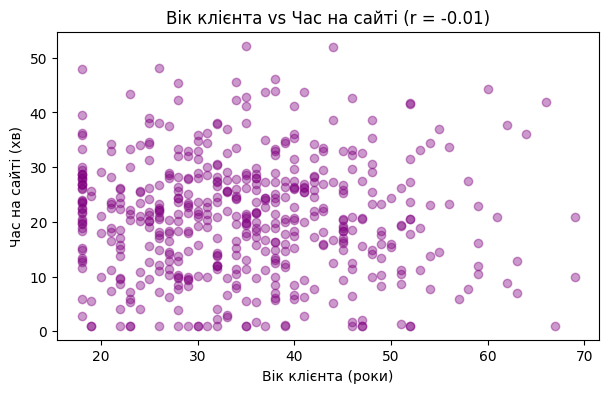

Статистично значущого зв'язку не виявлено


In [66]:
# Завдання 20:
r, p_value = stats.pearsonr(df["age"], df["session_min"])

print(f"Коефіцієнт кореляції r: {r:.3f}")
print(f"p-значення: {p_value:.4f}")


plt.figure(figsize=(7, 4))
plt.scatter(df["age"], df["session_min"], alpha=0.4, color="purple")
plt.xlabel("Вік клієнта (роки)")
plt.ylabel("Час на сайті (хв)")
plt.title(f"Вік клієнта vs Час на сайті (r = {r:.2f})")
plt.show()

if p_value < 0.05:
    print("Є статистично значущий зв'язок")
else:
    print("Статистично значущого зв'язку не виявлено")

#### 💬 Інтерпретація 22

Опишіть звʼязок (напрямок, сила, значущість).

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Зв'язок є зворотним, але надзвичайно слабким (r = -0,012), тобто практично відсутнім. p-значення = 0,7898 (> 0,05), тому цей зв'язок не є статистично значущим. Отже, за наявними даними не виявлено зв'язку між віком клієнта та часом, який він проводить на сайті.*

---
# 🎉 Вітаємо із завершенням!

Ви пройшли повний цикл роботи аналітика зі статистичними тестами:

- ✅ Одновибірковий, двовибірковий та парний t-тести
- ✅ ANOVA для 3+ груп
- ✅ Хі-квадрат для категоріальних даних
- ✅ Кореляція для числових змінних
- ✅ Повноцінний A/B-тест
- ✅ Самостійний вибір тесту під задачу

## Головне, що варто винести

1. **Вибір тесту** важливіший за код. Завжди питайте: який тип даних? скільки груп? незалежні чи парні?
2. **p-значення** саме по собі — це лише число. Цінність створює ваша **інтерпретація**.
3. **Контекст вирішує:** памʼятайте про розмір ефекту, практичну значущість і те, що кореляція ≠ причинність.

## Питання для самоперевірки
- Чи можете ви пояснити різницю між парним і двовибірковим t-тестом?
- Чому не можна замінити одну ANOVA трьома t-тестами?
- Що означає «не відхилили H₀» — чи це те саме, що «довели, що ефекту немає»?

Якщо на всі три питання ви відповідаєте впевнено — ви добре засвоїли тему. Так тримати! 📊
